# Process
### EXPLORATORY DATA ANALYSIS
### FEATURE ENGINEERING
### DATA PREPROCESSING
### DATA LOADING
### MODEL BUILDING
### MODEL TRAINING
### MODULARIZATION
### EXPERIMENT TRACKING
### MODEL EVALUATION
### INFERENCE PIPELINE
### API DEPLOYMENT
### DOCKERIZATION AND DCLOUD DEPLYOMENT 


# EXPLORATORY DATA ANALYSIS

## 1. Overview
## 2. Data Loading and Overview
## 3. Missing Values
## 4. Univariate Analysis
## 5. Bivariate Analysis
## 6. Correlations and Insights
## 7. Conclusions 

## 1. Overview

- This Stage is for the Exploratory Data Analysis of the Heart Disease csv data. 
- This process helps to identify any insights that could help with better training of the model
- the cell is where is install all the dependencies needed for the EDA, along with styles and theme

In [60]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import statsmodels
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

sns.set_theme(style="whitegrid", palette="deep", context="talk")

1. data collection
2. seperate data into features and targets
3. handle missing values and completeness
4. ensure correct data dtypes for analysis and modeling
5. handle univariate analysis of target data
6. handle univariate analysis of predictor data
7. check whither missing data correlates with the target
8. handle bivariate analysis for numerical and categorical data
9. establish a correlation structure & multicollinearity
10. check for outlifers and leverage points

## 2. Data Loading and Overview

- This stage loads the data and gives meaning to the feature labels
- In this stage, I also sepearate the features and targets, for better analysis

In [61]:
# data collection
data_frame = pd.read_csv('../data/raw/heart_disease.csv')
print(data_frame.shape)
display(data_frame.head())
display(data_frame.sample(5))
print(data_frame.dtypes)


(1025, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
173,39,0,2,94,199,0,1,179,0,0.0,2,0,2,1
324,48,1,1,130,245,0,0,180,0,0.2,1,0,2,1
391,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
766,57,1,0,110,335,0,1,143,1,3.0,1,1,3,0
564,56,1,0,132,184,0,0,105,1,2.1,1,1,1,0


age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object


Before going forward, I like to give the feature labels their context


- age = age: 29-77
- sex = what is the sex of the person: 1 = male, 0 = female
- trestbps = resting blood pressure: 94-200mm Hg
- cp = chest pain type (4 values): 0,1,2,3
- chol = serum cholestoral in mg/dl: 126 - 564 mg/dl
- fbs = fasting blood sugar > 120 mg/dl: 1 = true, 0 = false
- restecg = resting electrocardiographic results (values 0,1,2): 0-2
- thalach = maximum heart rate achieved: 71 - 202
- exang = exercise induced angina: 1 = yes, 0 = no
- oldpeak = ST depression induced by exercise relative to rest: 0-6.2
- slope = the slope of the peak exercise ST segment: 0-2
- ca = number of major vessels (0-3) colored by flourosopy: 0-3
- thal: 0 = normal; 1 = fixed defect; 2 = reversable defect
- The names and social security numbers of the patients were recently - removed from the database, replaced with dummy values.

In [62]:
# extract target from features
target_values = data_frame['target']
target = 'target'
features = [c for c in data_frame.columns if c != target]
feature_values = data_frame[features]
display(target_values.sample(10))
display(feature_values.sample(10))

748    1
274    1
995    1
717    0
116    0
439    0
380    0
657    1
112    0
179    0
Name: target, dtype: int64

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
522,67,0,2,152,277,0,1,172,0,0.0,2,1,2
25,61,0,0,145,307,0,0,146,1,1.0,1,0,3
843,59,1,3,160,273,0,0,125,0,0.0,2,0,2
246,54,1,1,192,283,0,0,195,0,0.0,2,1,3
599,63,0,1,140,195,0,1,179,0,0.0,2,2,2
166,56,1,0,132,184,0,0,105,1,2.1,1,1,1
753,65,1,0,120,177,0,1,140,0,0.4,2,0,3
10,71,0,0,112,149,0,1,125,0,1.6,1,0,2
91,62,0,0,124,209,0,1,163,0,0.0,2,0,2
850,58,1,1,120,284,0,0,160,0,1.8,1,0,2


Text(0.5, 1.0, 'Missingness Map')

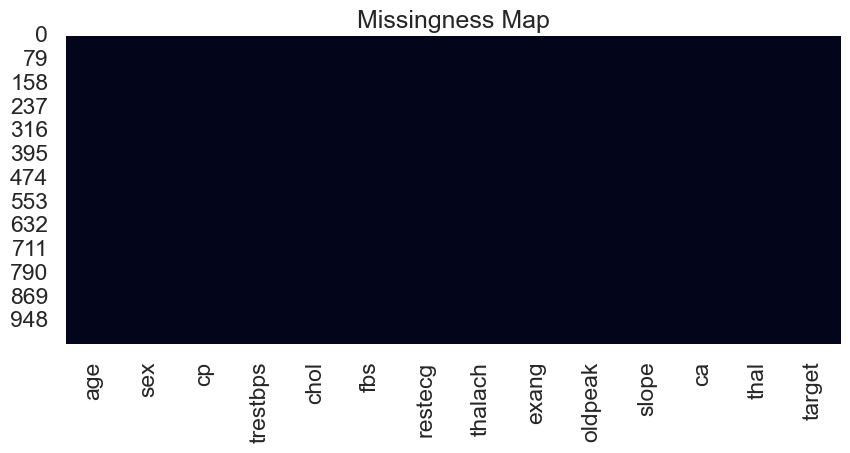

In [63]:
# handling missing values and completedness

# compute missing values AND their percentages
missing_data = data_frame.isna().sum().sort_values(ascending=False)
missing_percentage = (missing_data/len(data_frame))*100
pd.concat([missing_data, missing_percentage], axis=1, keys=['count','percentage']).head(20)
# visualize the missingness matrix through a heatmap
plt.figure(figsize=(10,4))
sns.heatmap(data_frame.isna(), cbar=False)
plt.title("Missingness Map")

In [64]:
# ensure correct data dtypes for analysis and modeling
categ_columns = data_frame.select_dtypes(include=['object']).columns
for c in categ_columns:
    print(c)

'''
    some of the categorical data is in int64 form. so we will instead, 
    look for the features that have few unique values.

    We will treat columns with few unique values or string data as categorical
'''
categ_columns = [col for col in data_frame.columns 
                 if data_frame[col].dtype == 'object' or
                 (data_frame[col].nunique() < 5 and data_frame[col].dtype in ['int64', 'float64'])]
print(categ_columns)
# convert the category features to type 'category'
for c in categ_columns:
    data_frame[c] = data_frame[c].astype('category')

# verify this type change
data_frame.info()

['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal', 'target']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   age       1025 non-null   int64   
 1   sex       1025 non-null   category
 2   cp        1025 non-null   category
 3   trestbps  1025 non-null   int64   
 4   chol      1025 non-null   int64   
 5   fbs       1025 non-null   category
 6   restecg   1025 non-null   category
 7   thalach   1025 non-null   int64   
 8   exang     1025 non-null   category
 9   oldpeak   1025 non-null   float64 
 10  slope     1025 non-null   category
 11  ca        1025 non-null   int64   
 12  thal      1025 non-null   category
 13  target    1025 non-null   category
dtypes: category(8), float64(1), int64(5)
memory usage: 57.3 KB


236     0
244     1
375     1
308     0
1001    1
305     0
49      0
496     0
394     0
239     0
Name: target, dtype: category
Categories (2, int64): [0, 1]

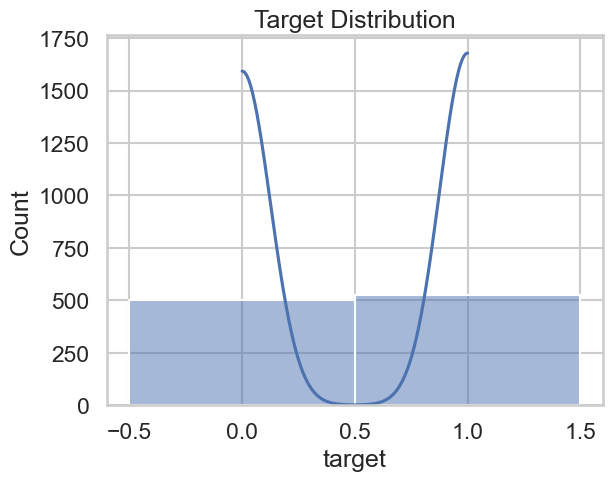

In [65]:
# univariate analysis - target first
'''
    we now must understand target distributions
'''
display(data_frame[target].sample(10))
data_frame[target].describe()
sns.histplot(data_frame[target], kde=True)
plt.title('Target Distribution')
plt.show()


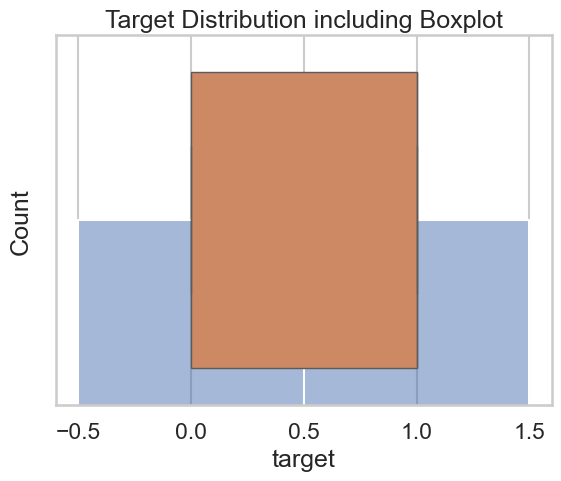

In [66]:
data_frame[target].describe()
sns.histplot(data_frame[target], kde=True)
plt.title('Target Distribution including Boxplot')
sns.boxplot(x=data_frame[target])
plt.show()

count    1025.000000
mean       54.434146
std         9.072290
min        29.000000
25%        48.000000
50%        56.000000
75%        61.000000
max        77.000000
Name: age, dtype: float64


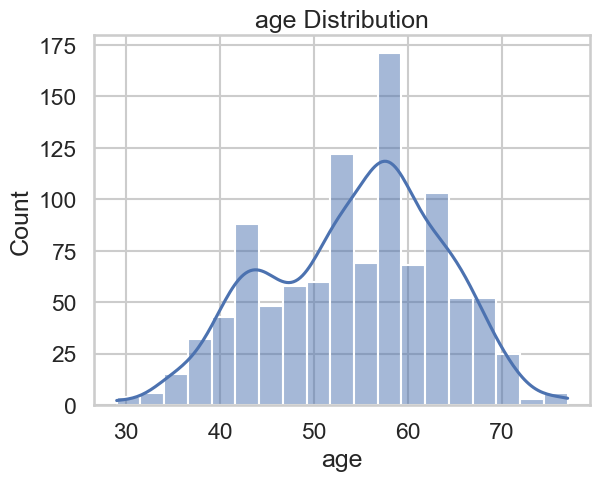

count    1025.000000
mean      131.611707
std        17.516718
min        94.000000
25%       120.000000
50%       130.000000
75%       140.000000
max       200.000000
Name: trestbps, dtype: float64


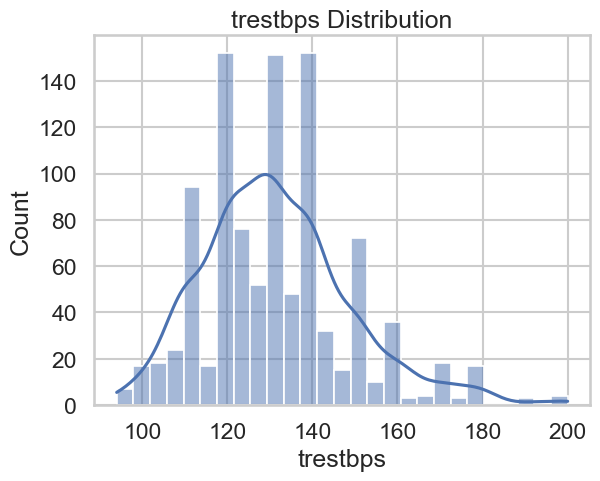

count    1025.00000
mean      246.00000
std        51.59251
min       126.00000
25%       211.00000
50%       240.00000
75%       275.00000
max       564.00000
Name: chol, dtype: float64


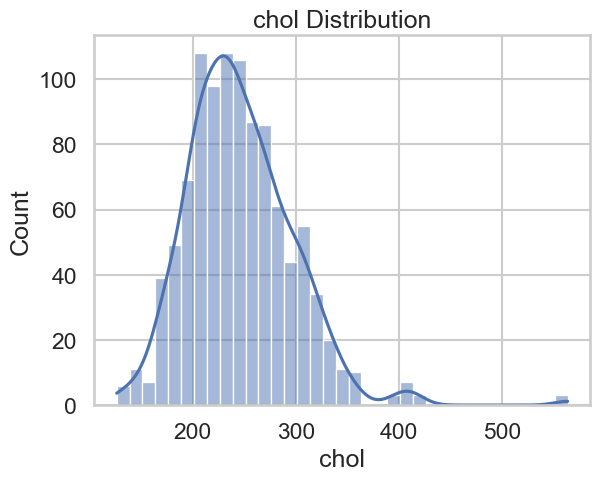

count    1025.000000
mean      149.114146
std        23.005724
min        71.000000
25%       132.000000
50%       152.000000
75%       166.000000
max       202.000000
Name: thalach, dtype: float64


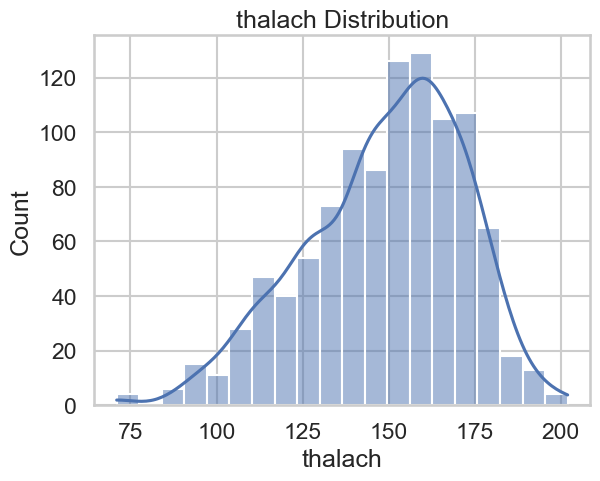

count    1025.000000
mean        1.071512
std         1.175053
min         0.000000
25%         0.000000
50%         0.800000
75%         1.800000
max         6.200000
Name: oldpeak, dtype: float64


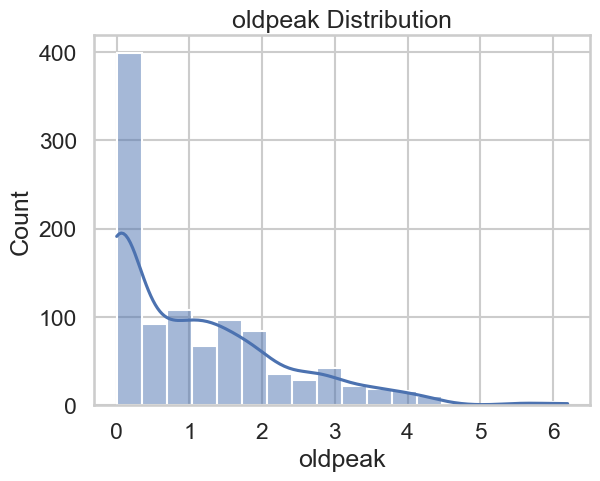

count    1025.000000
mean        0.754146
std         1.030798
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max         4.000000
Name: ca, dtype: float64


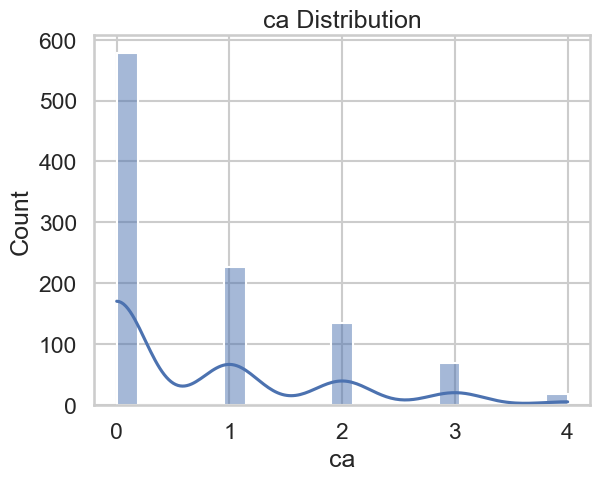

In [67]:
# univariate analysis - ALL PREDICTORS
'''
    all the predictors are the features of the dataframe
'''

# make distribution for numerical features
numerical_colums = data_frame.select_dtypes(include=['int64', 'float64']).columns
for c in numerical_colums:
    print(data_frame[c].describe())
    sns.histplot(data_frame[c].dropna(), kde=True)
    plt.title(f'{c} Distribution')
    plt.show()

sex count     1025
unique       2
top          1
freq       713
Name: sex, dtype: int64


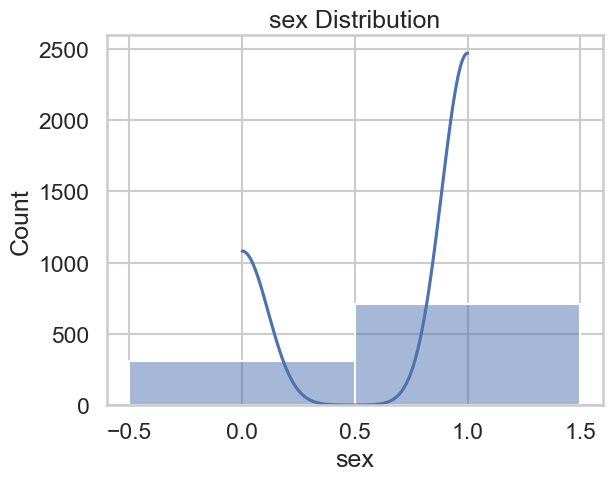

cp count     1025
unique       4
top          0
freq       497
Name: cp, dtype: int64


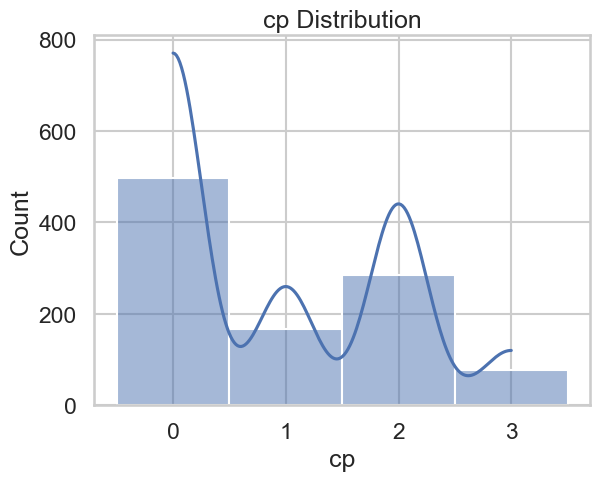

fbs count     1025
unique       2
top          0
freq       872
Name: fbs, dtype: int64


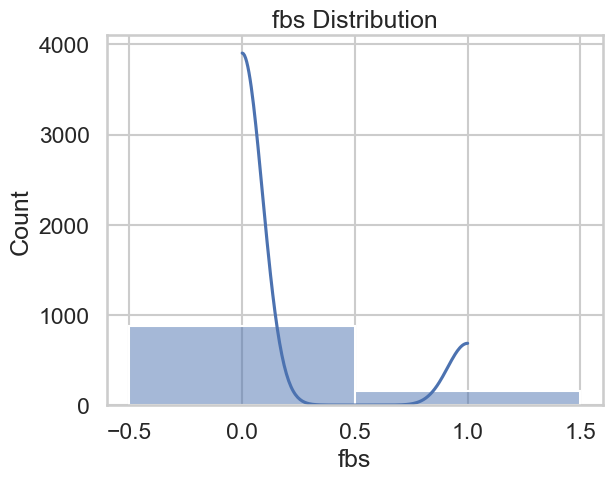

restecg count     1025
unique       3
top          1
freq       513
Name: restecg, dtype: int64


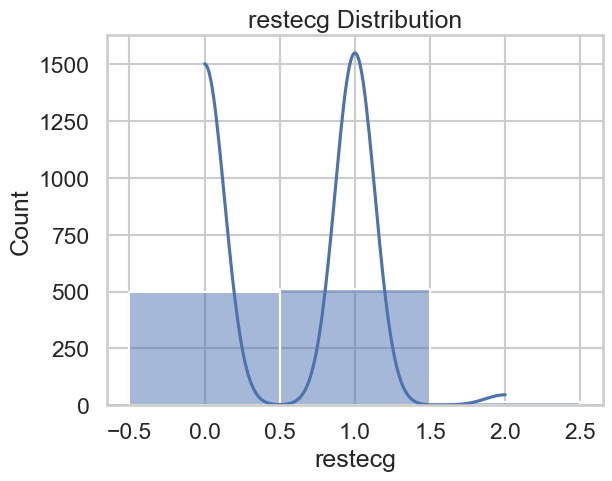

exang count     1025
unique       2
top          0
freq       680
Name: exang, dtype: int64


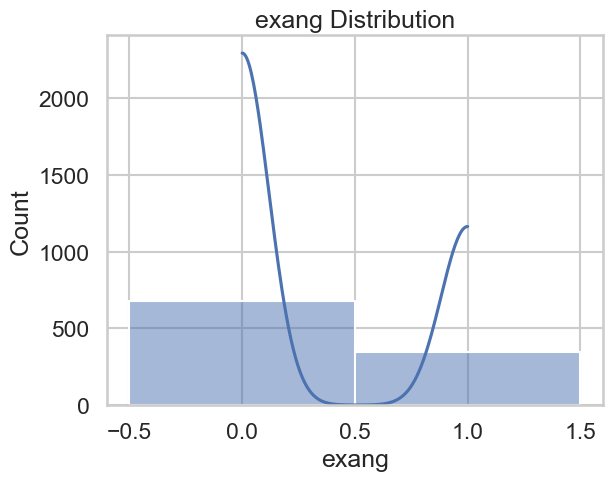

slope count     1025
unique       3
top          1
freq       482
Name: slope, dtype: int64


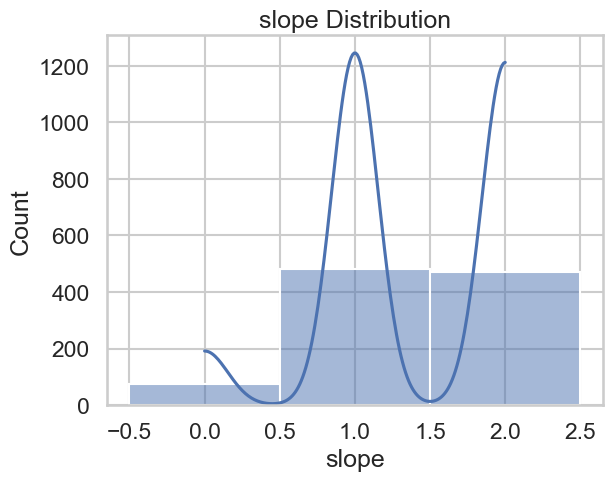

thal count     1025
unique       4
top          2
freq       544
Name: thal, dtype: int64


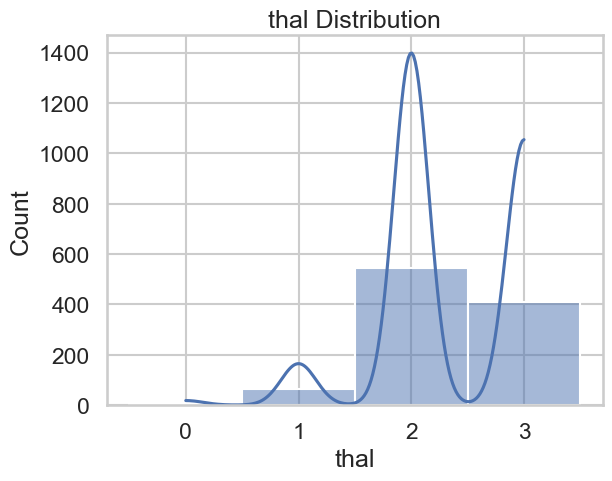

In [68]:
# get only categorical features

# data_frame[col].dtype == 'object'
categorical_colums = data_frame.select_dtypes(include=['category']).columns
cat_features = [c for c in categorical_colums if c != "target"]
for c in data_frame[cat_features].columns:
    print(c, data_frame[c].describe())
    sns.histplot(data_frame[c].dropna(), kde=True)
    plt.title(f'{c} Distribution')
    plt.show()

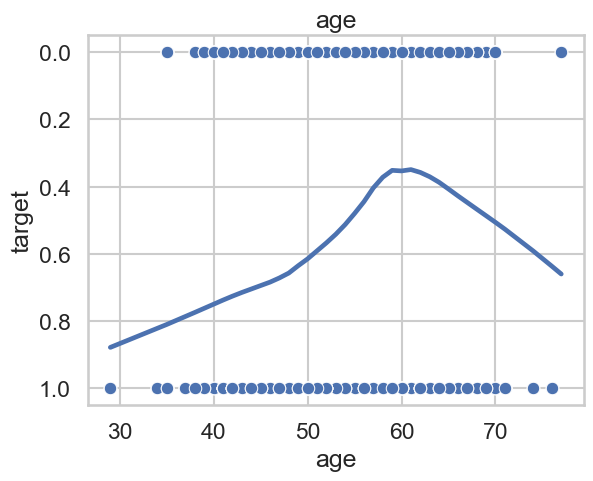

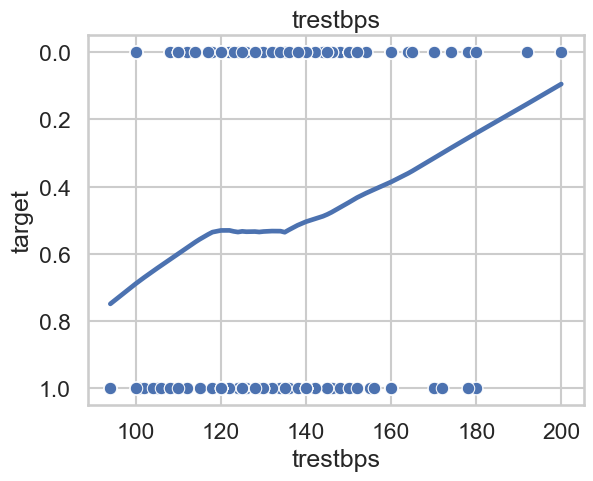

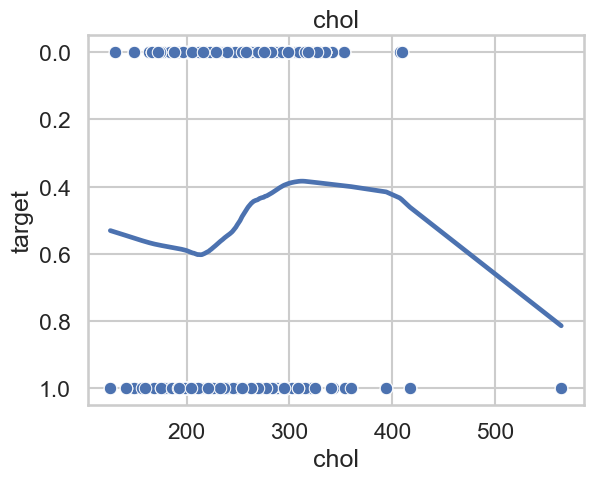

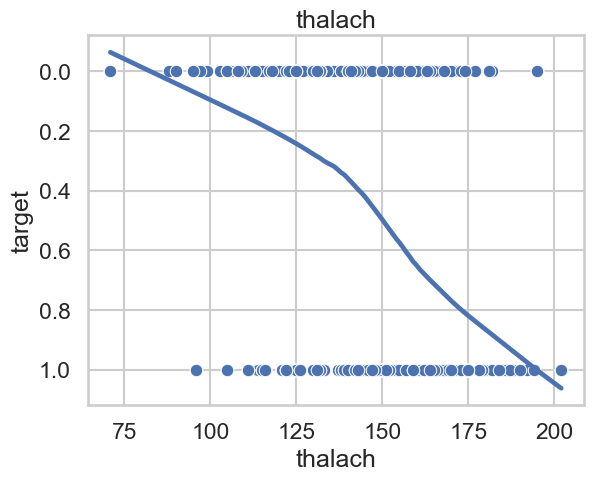

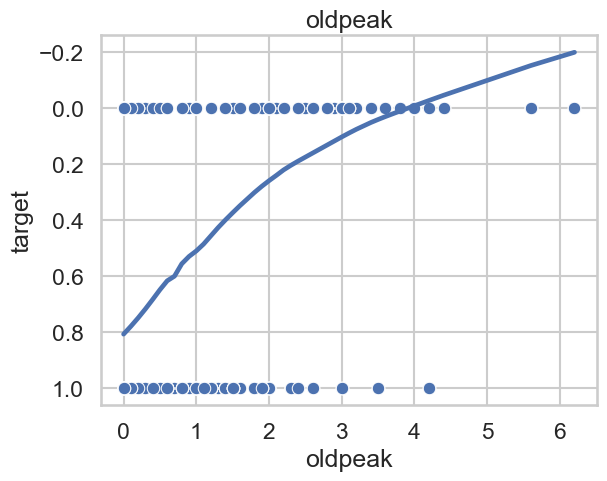

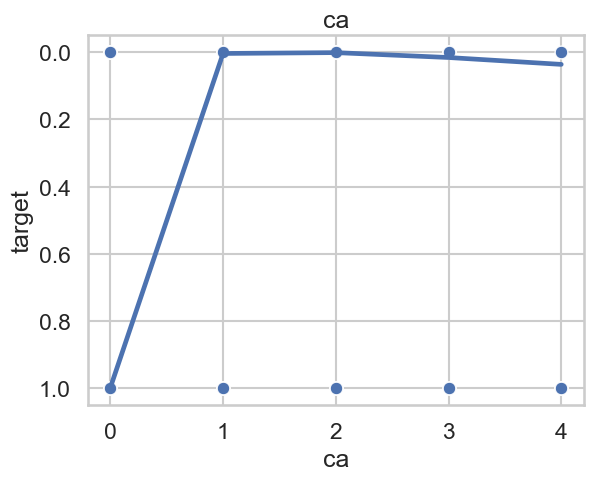

In [69]:
# Bivariate Analysis - feature vs target

for c in numerical_colums:
    sns.scatterplot(x=data_frame[c], y=data_frame[target])
    sns.regplot(x=data_frame[c], y=data_frame[target], lowess=True, scatter=False, ci=None)
    plt.title(c)
    plt.show()

,features,VIF
1,trestbps,55.332034
0,age,37.677299
3,thalach,29.575300
2,chol,24.335197
4,oldpeak,2.174525
5,ca,1.718157


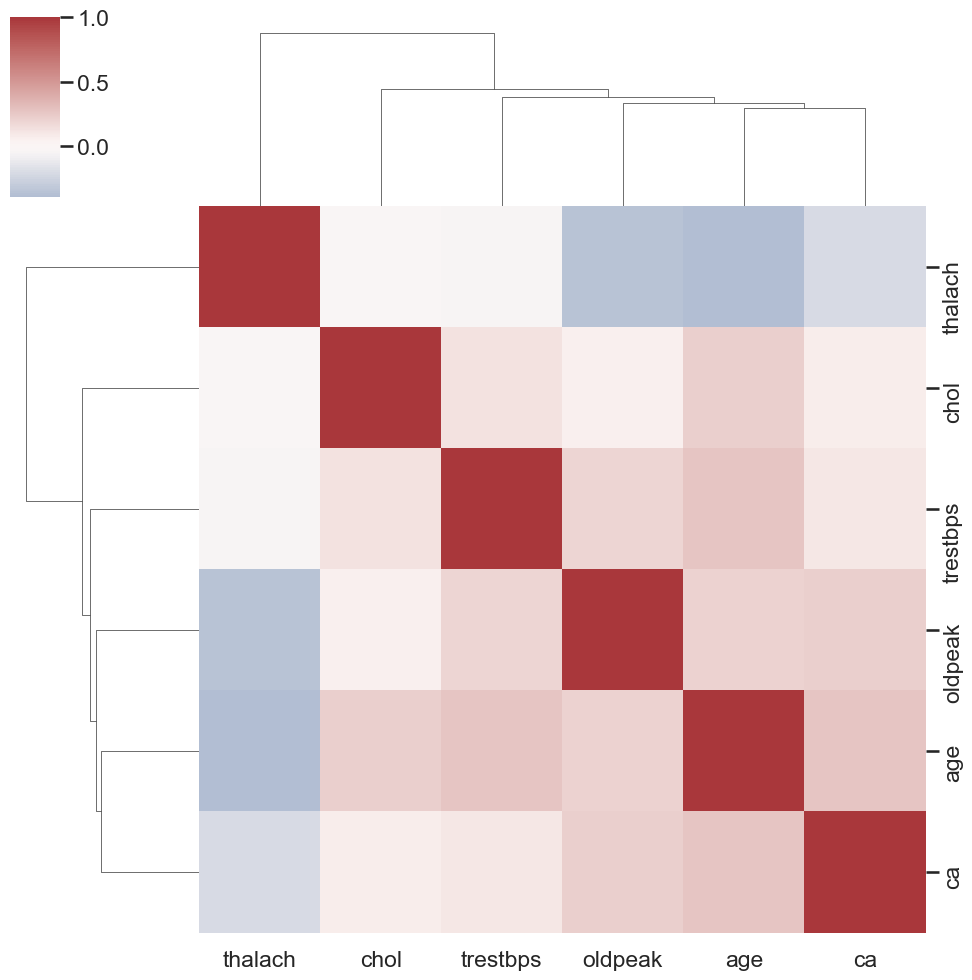

In [70]:
# correlation structure & multicollinearity
corr = data_frame[numerical_colums].corr()
sns.clustermap(corr, figsize=(10,10), cmap='vlag', center=0)

# VIF
X = data_frame[numerical_colums].dropna()
vif = pd.DataFrame({'features': X.columns, 'VIF': [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]})
vif.sort_values('VIF', ascending=False)

In [71]:
# outliers and Leverage Points

# detection of influential rows that can distort linear regression

# z-scores and IQR outliers for num features
from scipy import stats
z = np.abs(stats.zscore(data_frame[numerical_colums].dropna()))
outlier_rows = (z > 3).any(axis=1)
data_frame.loc[outlier_rows].shape

(49, 14)

In [72]:
data_frame.dtypes

age            int64
sex         category
cp          category
trestbps       int64
chol           int64
fbs         category
restecg     category
thalach        int64
exang       category
oldpeak      float64
slope       category
ca             int64
thal        category
target      category
dtype: object

In [73]:
# save new data to processed data folder
data_frame_cleaned = data_frame.copy()

data_frame_cleaned.to_csv('../data/processed/heart_disease_cleaned.csv', index=False)
print("Saved cleaned data to ../data/processed/eda_cleaned.csv")


Saved cleaned data to ../data/processed/eda_cleaned.csv
